# Tarea S11.01. Visualización de Datos con Python y Power BI

Descripción

Esta práctica integra el uso de Python con las librerías Pandas, Matplotlib, Seaborn o Plotly, así como su integración con Power BI.

Trabajarás todo el proceso, desde la conexión a MySQL, la creación de visualizaciones avanzadas en Python y, finalmente, la incorporación de estas visualizaciones en un informe dinámico de Power BI.

## Nivel 1
### ejercicio 1. 
Conecta Python con MySQL Workbench y carga los datos de tu base de datos del Sprint 4 para utilizarlos en todos los ejercicios.


In [1]:
import pandas as pd
import numpy as np

from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

## Nivel 1
### ejercicio 1. 
Conecta Python con MySQL Workbench y carga los datos de tu base de datos del Sprint 4 para utilizarlos en todos los ejercicios.

In [2]:
load_dotenv()

HOST = os.getenv("MYSQL_HOST")
DATABASE = os.getenv("MYSQL_DATABASE")
USER = os.getenv("MYSQL_USER")
PASSWORD = os.getenv("MYSQL_PASSWORD")

engine = create_engine(
    f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}/{DATABASE}"
)

print("Conexión realizada correctamente.")

Conexión realizada correctamente.


In [3]:
# CARGA DE MIS TABLAS DEL SPRINT 4
users = pd.read_sql("SELECT * FROM users", engine, parse_dates=["birth_date"])
companies = pd.read_sql("SELECT * FROM companies", engine)
credit_cards = pd.read_sql("SELECT * FROM credit_cards", engine)
transactions = pd.read_sql( "SELECT * FROM transactions",engine, parse_dates=["timestamp"])
products = pd.read_sql("SELECT * FROM products", engine)
transaction_products = pd.read_sql( "SELECT * FROM transaction_products", engine)
card_status = pd.read_sql( "SELECT * FROM card_status", engine)
# revisar globals
print("Tablas cargadas correctamente.")

Tablas cargadas correctamente.


In [4]:
# COMPROBACION DE LOS DATOS CARGADOS

transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   id           100000 non-null  str           
 1   card_id      100000 non-null  str           
 2   business_id  100000 non-null  str           
 3   timestamp    100000 non-null  datetime64[us]
 4   amount       100000 non-null  float64       
 5   declined     100000 non-null  int64         
 6   product_ids  100000 non-null  str           
 7   user_id      100000 non-null  int64         
 8   lat          100000 non-null  float64       
 9   longitude    100000 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(2), str(4)
memory usage: 7.6 MB


In [5]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            100 non-null    str    
 1   product_name  100 non-null    str    
 2   price_$       100 non-null    float64
 3   colour        100 non-null    str    
 4   weight_kg     100 non-null    float64
 5   warehouse_id  100 non-null    str    
dtypes: float64(2), str(4)
memory usage: 4.8 KB


In [6]:
users.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype        
---  ------       --------------  -----        
 0   id           5000 non-null   int64        
 1   name         5000 non-null   str          
 2   surname      5000 non-null   str          
 3   phone        5000 non-null   str          
 4   email        5000 non-null   str          
 5   birth_date   5000 non-null   datetime64[s]
 6   country      5000 non-null   str          
 7   city         5000 non-null   str          
 8   postal_code  5000 non-null   str          
 9   address      5000 non-null   str          
 10  region       5000 non-null   str          
dtypes: datetime64[s](1), int64(1), str(9)
memory usage: 429.8 KB


In [7]:
# RENOMBRAR COLUMNAS CON NOMBRES SIMILARES
#  users
users = users.rename(columns={

    "id": "user_id",

    "country": "user_country",

    "phone": "user_phone",

    "email": "user_email",

    "region": "user_region"

})


# companies

companies = companies.rename(columns={

    "country":"company_country",

    "phone":"company_phone",

    "email":"company_email"

})
# credit cards

credit_cards = credit_cards.rename(columns={

    "id":"card_id",

    "user_id":"card_user_id"

})


transactions = transactions.rename(columns={"id": "transaction_id"})


In [8]:
#data frame principal
df = transactions.merge( users, on="user_id", how="left")
df = df.merge( companies, left_on="business_id", right_on="company_id", how="left")
df = df.merge( credit_cards, on="card_id", how="left")
df = df.merge( card_status, on="card_id", how="left")


In [9]:
df.head()

,transaction_id,card_id,business_id,timestamp,amount,declined,product_ids,user_id,lat,longitude,...,website,card_user_id,iban,pan,pin,cvv,track1,track2,expiring_date,status
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,0,"16, 26, 97, 87",4713,46.199929,1.435540,...,https://wikipedia.org/user/110\r,4713,XX691799023254713153661899,9905956087984517,4449,208,%B9905956087984517^VXEWRVVXEWRV^33040000000000...,%B9905956087984517=3303101273348688?,2025-02-25,active
1,000447FE-B650-4DCF-85DE-C7ED0EE1CAAD,CcS-5019,b-2370,2016-12-21 20:07:18,155.63,0,"66, 69, 87",438,41.597206,12.221760,...,https://baidu.com/en-us\r,438,XX6146257567440323960205,8026624008893903,5268,462,%B8026624008893903^BHSSKCBHSSKC^24040000000000...,%B8026624008893903=3402101156166603?,2025-03-27,active
2,00045D6B-ED2E-4F2F-8186-CEE074D875D0,CcS-6699,b-2390,2020-07-14 15:37:45,326.01,0,"30, 11, 16, 81",2118,29.757296,-95.379637,...,https://whatsapp.com/sub/cars\r,2118,XX715219809262791935275891,6057650350590623,7313,437,%B6057650350590623^ZNHTJDZNHTJD^30120000000000...,%B6057650350590623=2911101162571775?,2026-03-29,active
3,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,CcS-6696,b-2230,2017-09-04 19:44:53,161.60,0,72,2115,53.548884,-113.503053,...,https://pinterest.com/sub/cars\r,2115,XX785022829713140880782522,5592939367453050,2612,402,%B5592939367453050^IMAKXRIMAKXR^25040000000000...,%B5592939367453050=2309101751548212?,2028-11-28,active
4,00051AA4-9CBE-4268-B070-C38062A1B3E2,CcS-7606,b-2266,2017-01-05 18:19:25,148.91,0,18,3025,52.208370,5.690806,...,https://instagram.com/group/9\r,3025,XX634626564536875934323485,8091873035153937,5114,688,%B8091873035153937^ZPBKIEZPBKIE^22060000000000...,%B8091873035153937=3401101322733863?,2029-11-25,active


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 35 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   transaction_id   100000 non-null  str           
 1   card_id          100000 non-null  str           
 2   business_id      100000 non-null  str           
 3   timestamp        100000 non-null  datetime64[us]
 4   amount           100000 non-null  float64       
 5   declined         100000 non-null  int64         
 6   product_ids      100000 non-null  str           
 7   user_id          100000 non-null  int64         
 8   lat              100000 non-null  float64       
 9   longitude        100000 non-null  float64       
 10  name             100000 non-null  str           
 11  surname          100000 non-null  str           
 12  user_phone       100000 non-null  str           
 13  user_email       100000 non-null  str           
 14  birth_date       100000 non-null

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df_sample = df.sample(5000, random_state=42) # Esta muestra NO se usa para los cálculos, solo para los gráficos de dispersión (scatterplot) y pairplot.

### ejercicio 2. 
Para cada uno de los siguientes puntos, crea una visualización adecuada según las variables especificadas. Interpreta los resultados de acuerdo con tus datos.
Recuerda: al seleccionar las columnas, piensa siempre en el método que vas a utilizar e incluye todas las que sean necesarias para la función de visualización que desees emplear.
Realiza una visualización para cada uno de los siguientes casos:
#### ejecicio 2.1 Una variable numérica: El histograma es adecuado porque permite observar la distribución de los valores.

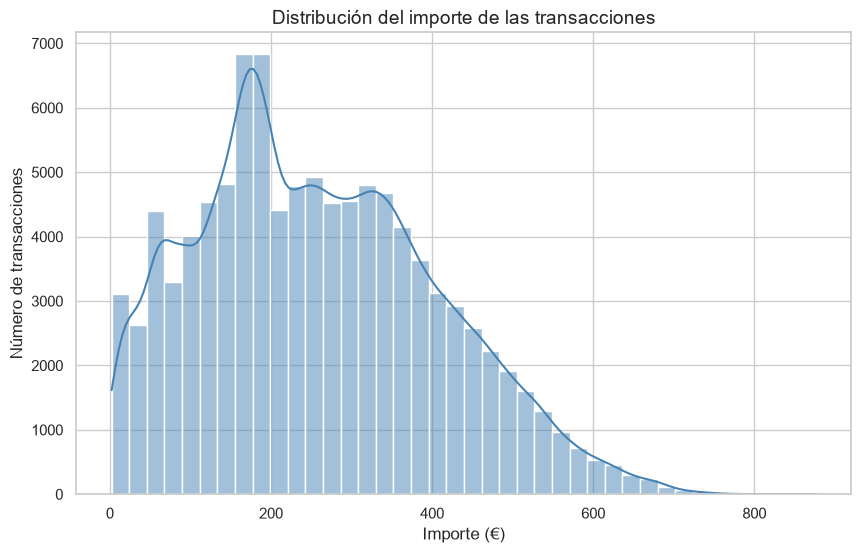

In [13]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="amount",
    bins=40,
    kde=True,
    color="steelblue"
)

plt.title(
    "Distribución del importe de las transacciones",
    fontsize=14
)

plt.xlabel("Importe (€)")
plt.ylabel("Número de transacciones")

plt.show()

La distribución del importe muestra que la mayoría de las transacciones se concentran en valores bajos y medios. La presencia de una cola hacia la derecha indica que existen algunas operaciones con importes elevados, aunque son menos frecuentes.

#### ejecicio 2.2 Dos variables numéricas - Scatter numérico-numérico

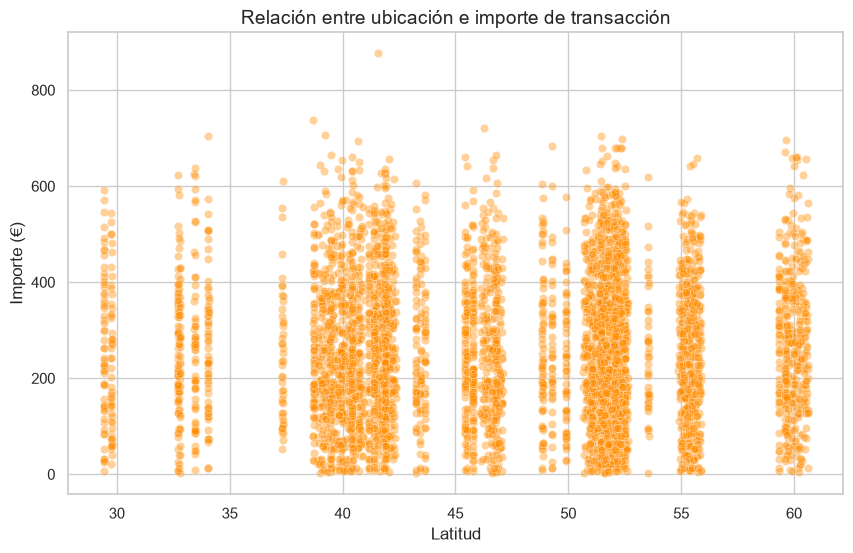

In [14]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_sample,
    x="lat",
    y="amount",
    alpha=0.4,
    color="darkorange"
)

plt.title(
    "Relación entre ubicación e importe de transacción",
    fontsize=14
)

plt.xlabel("Latitud")
plt.ylabel("Importe (€)")

plt.show()

No se observa una relación lineal clara entre la latitud y el importe de las transacciones. Esto indica que la ubicación geográfica no parece determinar directamente el valor económico de las compras.

#### ejecicio 2.3 Una variable categórica - Countplot categórica

C:\Users\user\AppData\Local\Temp\ipykernel_24808\3421703781.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


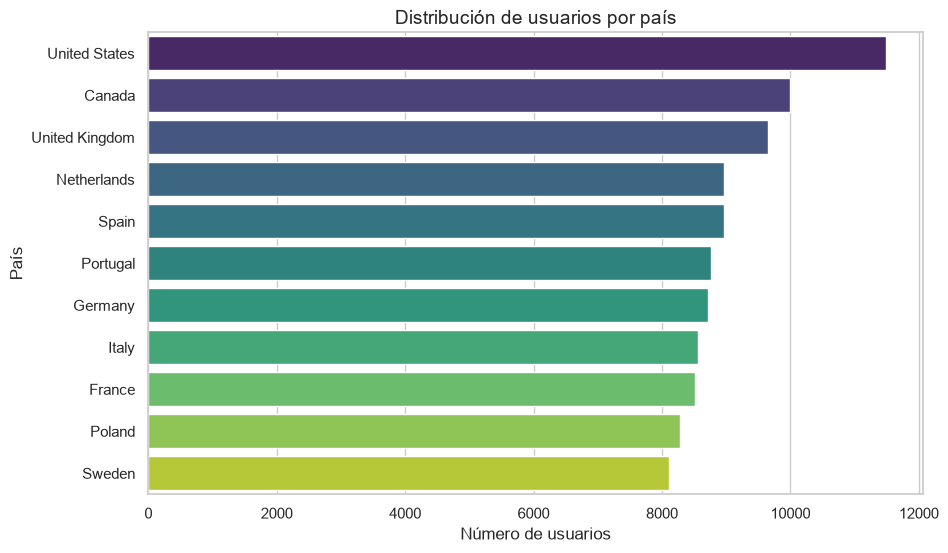

In [15]:
plt.figure(figsize=(10,6))

top_countries = (
    df["user_country"]
    .value_counts()
    .head(15)
    .index
)


sns.countplot(
    data=df[df["user_country"].isin(top_countries)],
    y="user_country",
    order=top_countries,
    palette="viridis"
)

plt.title(
    "Distribución de usuarios por país",
    fontsize=14
)

plt.xlabel("Número de usuarios")
plt.ylabel("País")

plt.show()

La distribución muestra los países con mayor representación dentro de la base de usuarios. Esto permite identificar los mercados donde existe mayor presencia de clientes.

#### ejecicio 2.4 Una variable categórica y una variable numérica - Boxplot categórica-numérica


C:\Users\user\AppData\Local\Temp\ipykernel_24808\1370711451.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


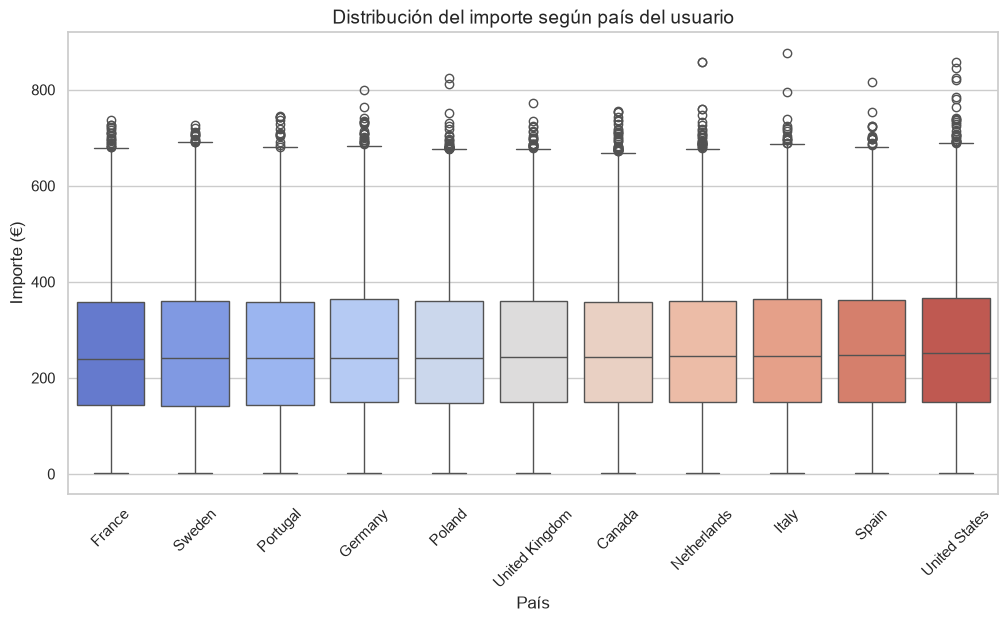

In [16]:
plt.figure(figsize=(12,6))


order_country = (
    df.groupby("user_country")["amount"]
    .median()
    .sort_values()
    .index
)


sns.boxplot(
    data=df,
    x="user_country",
    y="amount",
    order=order_country,
    palette="coolwarm"
)


plt.xticks(rotation=45)

plt.title(
    "Distribución del importe según país del usuario",
    fontsize=14
)

plt.xlabel("País")
plt.ylabel("Importe (€)")


plt.show()

El gráfico permite comparar el comportamiento del gasto entre países. Se observan diferencias en la distribución de los importes, así como posibles valores atípicos asociados a compras de mayor valor.

#### ejecicio 2.5 Dos variables categóricas.


In [17]:
df["transaction_status"] = df["declined"].map({
    0: "Aceptada",
    1: "Rechazada"
})

In [20]:
df_sample = df.sample( 5000, random_state=42 ) # df_sample no se actualiza automáticamente y se requiere especificar el valor o el rango que se esta tomando dentro del nuevo df_sample

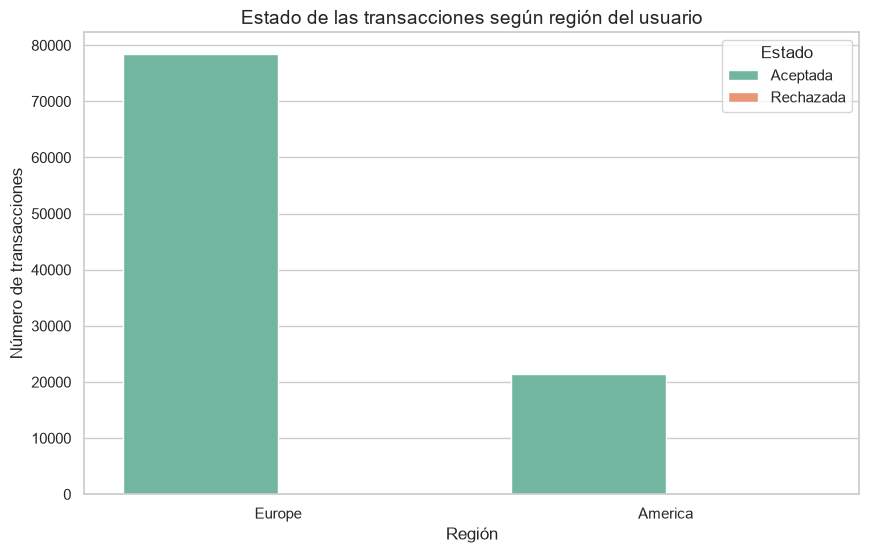

In [21]:
plt.figure(figsize=(10,6))


sns.countplot(
    data=df,
    x="user_region",
    hue="transaction_status",
    palette="Set2"
)


plt.title(
    "Estado de las transacciones según región del usuario",
    fontsize=14
)

plt.xlabel("Región")
plt.ylabel("Número de transacciones")

plt.legend(
    title="Estado"
)

plt.show()

El gráfico permite comparar la cantidad de transacciones aceptadas y rechazadas según la región del usuario. Se observa la proporción de operaciones rechazadas frente a aceptadas y permite identificar si existe alguna diferencia significativa entre regiones.

#### ejecicio 2.6 Tres variables combinadas.


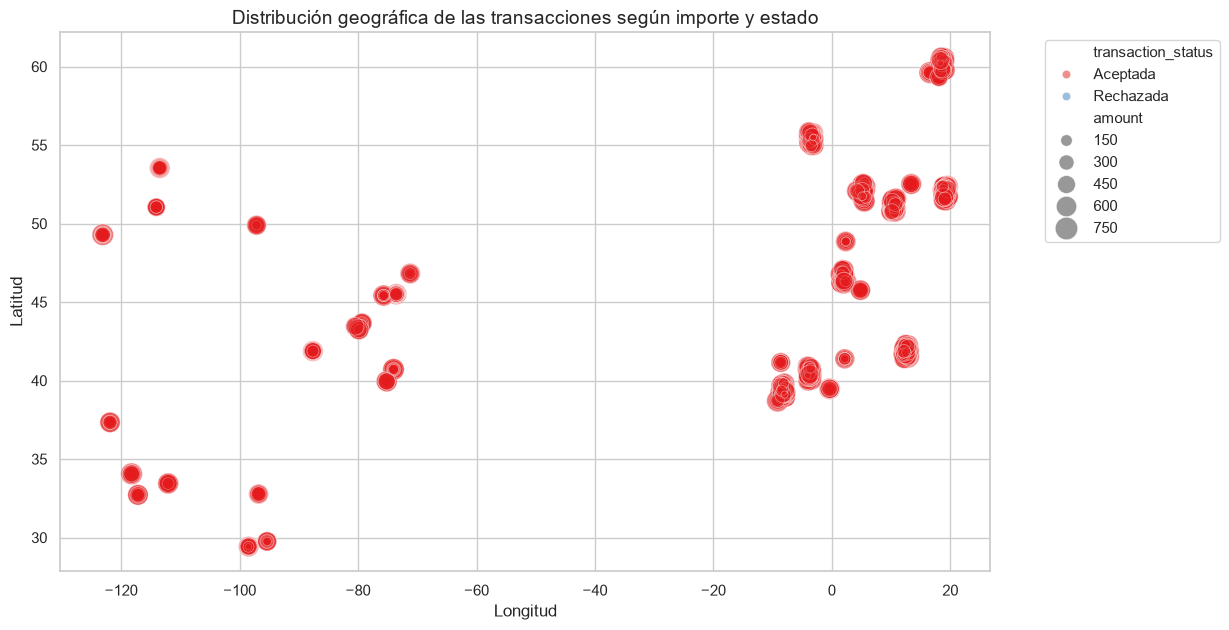

In [22]:
plt.figure(figsize=(12,7))


sns.scatterplot(
    data=df_sample,
    x="longitude",
    y="lat",
    hue="transaction_status",
    size="amount",
    sizes=(20,300),
    alpha=0.5,
    palette="Set1"
)


plt.title(
    "Distribución geográfica de las transacciones según importe y estado",
    fontsize=14
)

plt.xlabel("Longitud")
plt.ylabel("Latitud")

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.show()

La visualización permite observar la distribución espacial de las transacciones, diferenciando entre operaciones aceptadas y rechazadas. El tamaño de los puntos representa el importe, permitiendo identificar zonas donde se concentran transacciones de mayor valor.

#### ejecicio 2.7 Crea un Pairplot.

In [23]:
pairplot_data = df_sample[
    [
        "amount",
        "lat",
        "longitude",
        "declined"
    ]
]

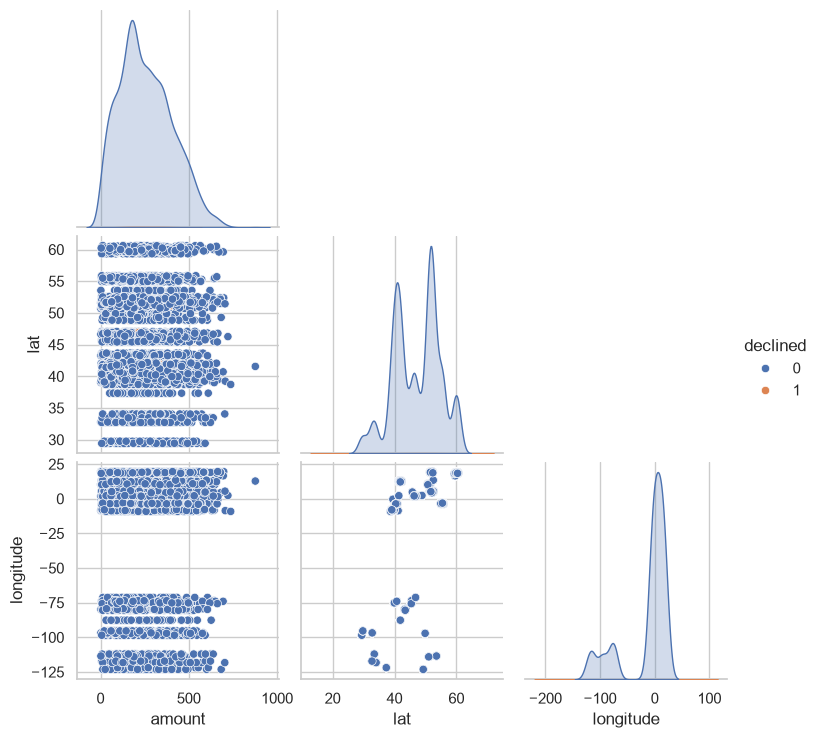

In [24]:
sns.pairplot(
    pairplot_data,
    hue="declined",
    corner=True
)

plt.show()

El pairplot permite observar las relaciones entre variables numéricas. No se identifican correlaciones lineales fuertes entre el importe y la ubicación geográfica. La variable declined permite comparar si existen diferencias visuales entre transacciones aceptadas y rechazadas.

## Nivel 2
### ejercicio 1. 
Representa la correlación entre algunas variables e interpreta los resultados de acuerdo con tus datos.

In [25]:
corr = df[
    [
        "amount",
        "lat",
        "longitude",
        "declined"
    ]
].corr()

corr

,amount,lat,longitude,declined
amount,1.000000,-0.008176,-0.005780,0.013513
lat,-0.008176,1.000000,0.504625,-0.017668
longitude,-0.005780,0.504625,1.000000,-0.028616
declined,0.013513,-0.017668,-0.028616,1.000000


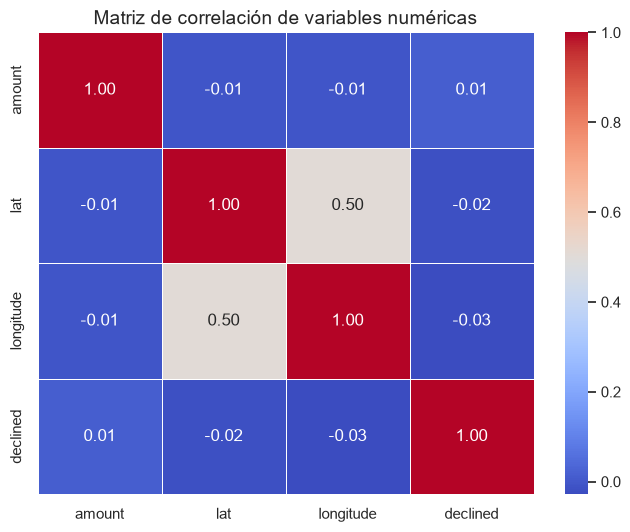

In [26]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Matriz de correlación de variables numéricas",
    fontsize=14
)

plt.show()

La matriz de correlación permite observar la relación lineal entre las variables numéricas. El importe (amount) no presenta una correlación fuerte con las coordenadas geográficas (lat y longitude), indicando que la localización no determina directamente el valor económico de una transacción. La variable declined tampoco muestra una relación significativa con el importe, por lo que los rechazos no parecen depender únicamente del valor de compra.

### ejercicio 2. 
Implementa un Jointplot para explorar la relación entre dos variables e interpreta los resultados de acuerdo con tus datos.

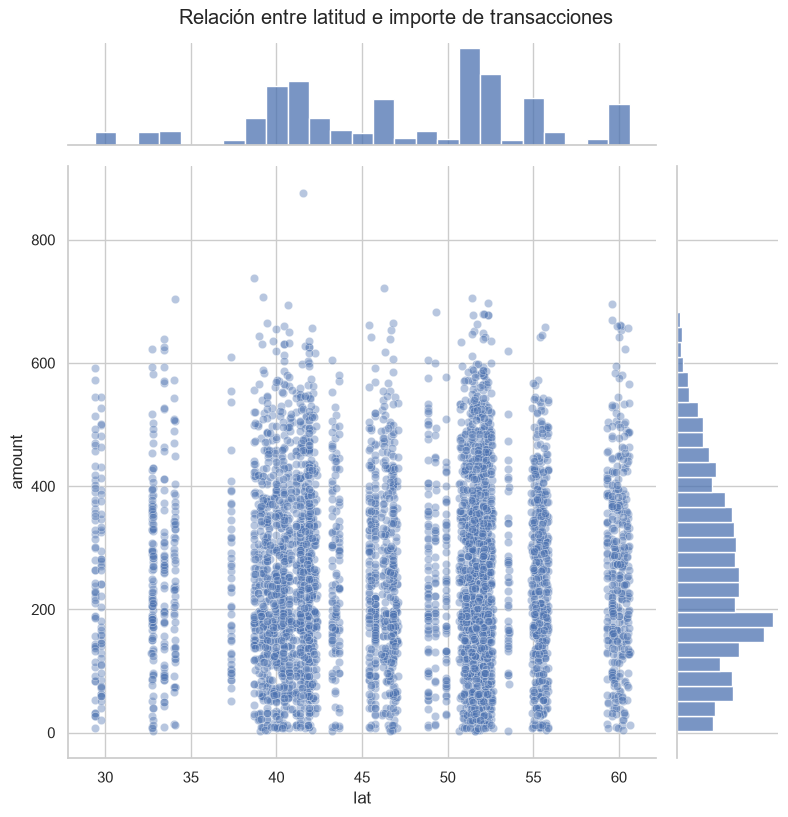

In [27]:
sns.jointplot(
    data=df_sample,
    x="lat",
    y="amount",
    kind="scatter",
    height=8,
    alpha=0.4
)

plt.suptitle(
    "Relación entre latitud e importe de transacciones",
    y=1.02
)

plt.show()

El jointplot permite analizar simultáneamente la distribución individual de cada variable y su relación conjunta. La nube de puntos muestra que no existe una relación lineal evidente entre la latitud y el importe de las transacciones. Los importes elevados aparecen distribuidos en diferentes posiciones geográficas.

## Nivel 3
### ejercicio 1. 
Transfiere todas las visualizaciones del Nivel 1 a Power BI utilizando scripts de Python.

Recuerda: cuando cargues tus DataFrames en Power BI, asegúrate de incluir una columna identificadora o una combinación de columnas que garantice la unicidad de cada registro. De forma predeterminada, Power BI elimina los registros duplicados, por lo que podrías perder información.

In [28]:
df.head()

,transaction_id,card_id,business_id,timestamp,amount,declined,product_ids,user_id,lat,longitude,...,card_user_id,iban,pan,pin,cvv,track1,track2,expiring_date,status,transaction_status
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,0,"16, 26, 97, 87",4713,46.199929,1.435540,...,4713,XX691799023254713153661899,9905956087984517,4449,208,%B9905956087984517^VXEWRVVXEWRV^33040000000000...,%B9905956087984517=3303101273348688?,2025-02-25,active,Aceptada
1,000447FE-B650-4DCF-85DE-C7ED0EE1CAAD,CcS-5019,b-2370,2016-12-21 20:07:18,155.63,0,"66, 69, 87",438,41.597206,12.221760,...,438,XX6146257567440323960205,8026624008893903,5268,462,%B8026624008893903^BHSSKCBHSSKC^24040000000000...,%B8026624008893903=3402101156166603?,2025-03-27,active,Aceptada
2,00045D6B-ED2E-4F2F-8186-CEE074D875D0,CcS-6699,b-2390,2020-07-14 15:37:45,326.01,0,"30, 11, 16, 81",2118,29.757296,-95.379637,...,2118,XX715219809262791935275891,6057650350590623,7313,437,%B6057650350590623^ZNHTJDZNHTJD^30120000000000...,%B6057650350590623=2911101162571775?,2026-03-29,active,Aceptada
3,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,CcS-6696,b-2230,2017-09-04 19:44:53,161.60,0,72,2115,53.548884,-113.503053,...,2115,XX785022829713140880782522,5592939367453050,2612,402,%B5592939367453050^IMAKXRIMAKXR^25040000000000...,%B5592939367453050=2309101751548212?,2028-11-28,active,Aceptada
4,00051AA4-9CBE-4268-B070-C38062A1B3E2,CcS-7606,b-2266,2017-01-05 18:19:25,148.91,0,18,3025,52.208370,5.690806,...,3025,XX634626564536875934323485,8091873035153937,5114,688,%B8091873035153937^ZPBKIEZPBKIE^22060000000000...,%B8091873035153937=3401101322733863?,2029-11-25,active,Aceptada


In [33]:
import os

os.getcwd()

'c:\\Users\\user\\Desktop\\PRACTICAS ANALIST DE DATOS\\PYTHON\\SPRINT 11'

In [34]:
df.to_csv(
    "df_powerbi.csv",
    index=False
)

In [35]:
os.listdir()

['.env',
 'df_powerbi.csv',
 'FU_Sprint04_PDF.pdf',
 'sprint  11 BL.pbix',
 'sprint_11 - Copy.ipynb',
 'Sprint_11 didac.ipynb',
 'sprint_11.ipynb',
 'SPRINT_11_REV.ipynb',
 'store_transactions_powerbi.csv',
 'Tarea S11.docx']

In [36]:
os.getcwd()

'c:\\Users\\user\\Desktop\\PRACTICAS ANALIST DE DATOS\\PYTHON\\SPRINT 11'